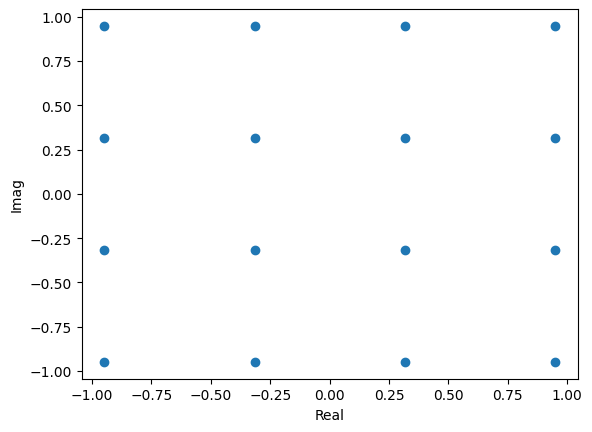

In [19]:
import numpy as np
from scipy import signal
import komm
from matplotlib import pyplot as plt
from tools import *

np.random.seed(0)

msg = "A perfectly acceptable example of an extremely verbose message of large words and many characters!!!"
M = 16
fc = 1e6
br = 50e3
fs = 6e6
sps = int(fs / br)
sps_rx = 4
snr = 10
Es = 1
B = 250e3 # channel BW

sync_len = 64
zadoff_chu_len = 16
span = 14
beta = 0.5

constellation = get_const(f'{M}-QAM', Es)
plot_constellation(constellation)
plt.show()

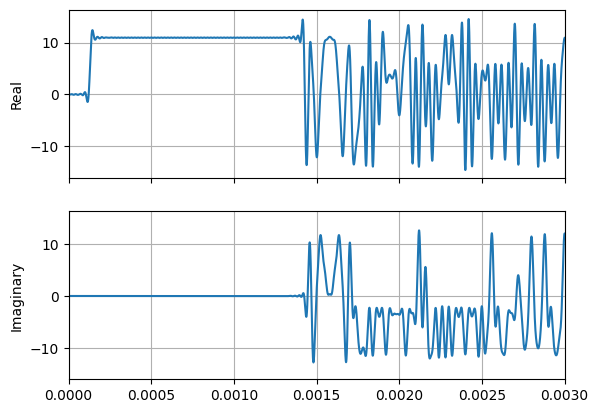

In [20]:
words = str2words(msg, M)
symbs = constellation[words]
sync_symbs = np.ones(sync_len) + 0j
zadoff_chu_seq = zadoff_chu(zadoff_chu_len)

rrc = get_rrc_pulse(beta, span, sps)

# full_msg = np.convolve(upsample(np.concat((sync_symbs, zadoff_chu_seq, symbs)), sps), rrc)
full_msg = signal.resample_poly(np.pad(np.concat((sync_symbs, zadoff_chu_seq, symbs)), span//2), sps, 1, window=rrc)

fig, ax1, ax2 = plot_complex_time_sequence(full_msg, fs)
plt.xlim((0.0000, 0.003))
plt.show()

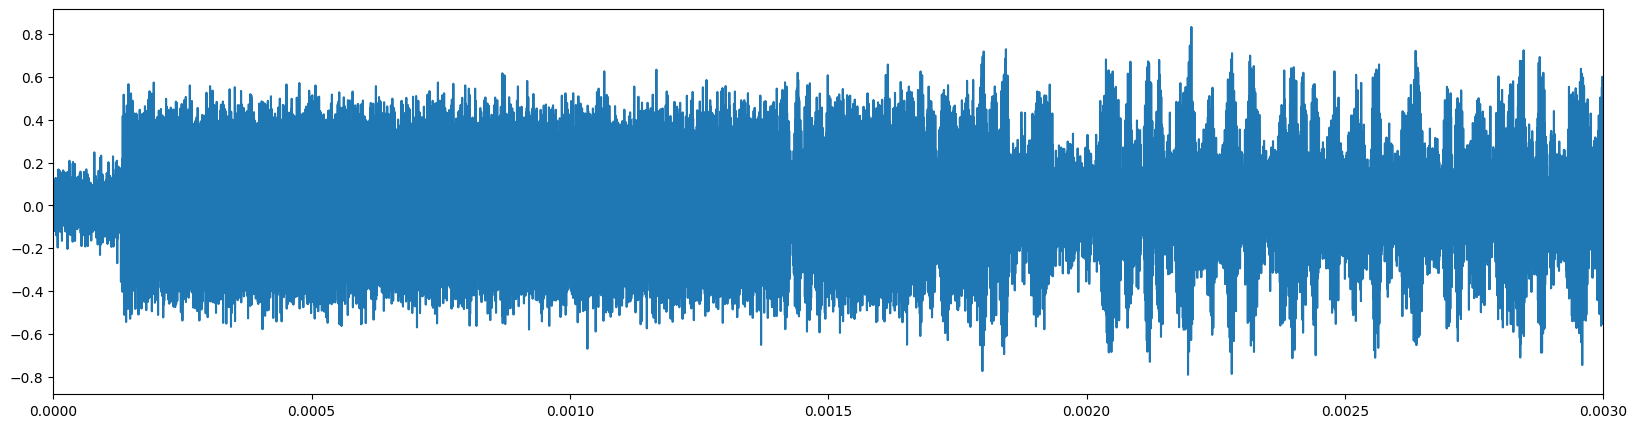

In [21]:
t = np.arange(0, len(full_msg)) / fs
x = np.real(full_msg * np.exp(2j*np.pi*fc*t))

channel = signal.TransferFunction([0, B, 0], [1, B, fc**2])
trx, chout = signal.dlsim(signal.cont2discrete(channel, 1/fs, 'bilinear'), x, t)
awgn = komm.AWGNChannel('measured', 10**(snr/10))
noisy_chout = awgn.transmit(np.squeeze(chout))

plt.figure(figsize=(20, 5))
plt.plot(trx, noisy_chout)
plt.xlim((0.000, 0.003))
plt.show()


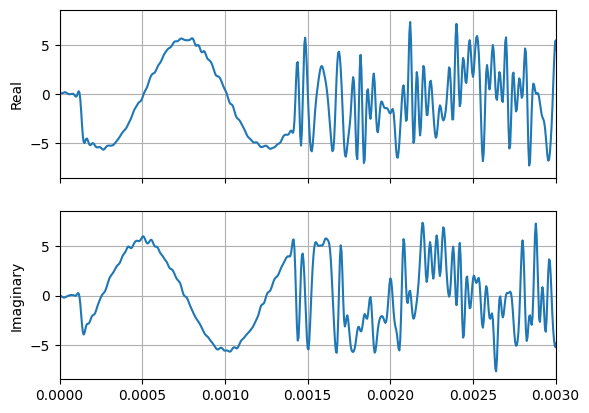

In [22]:
demod_filt = signal.iirfilter(3, fc, btype='lowpass', fs=fs)
b, a = demod_filt

phase_offset = 11*np.pi/37
cfo = fc * 0.001
gain = 1

lo = gain * np.exp(-2j*np.pi*(fc + cfo)*trx + phase_offset)

y = signal.lfilter(b, a, (noisy_chout * lo)).T


# yhat = np.convolve(np.squeeze(y), rrc, 'same')
yhat = signal.resample_poly(np.squeeze(y), 1, sps//sps_rx, window=rrc)
fig, ax1, ax2 = plot_complex_time_sequence(yhat, br*sps_rx)
plt.xlim((0, 0.003))
plt.show()
# animate_complex_sequence(yhat[t < 0.00125], 'Simulated CFO', 'cfo.mp4', sps=360)

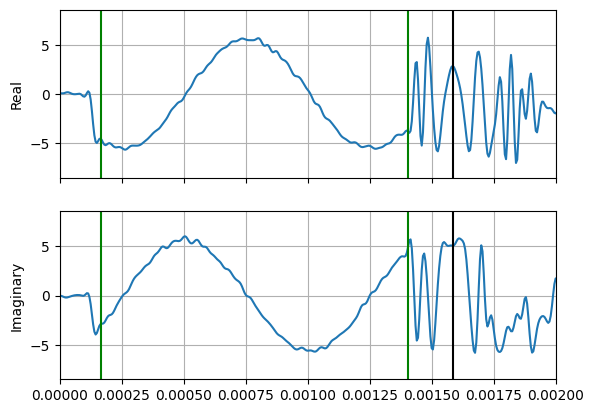

In [23]:
zch_rc = np.convolve(upsample(zadoff_chu_seq, sps_rx), get_rc_pulse(beta, span, sps_rx), 'same')

xcorr = np.abs(np.correlate(yhat, zch_rc, 'same'))
sync_point = np.argmax(xcorr)
pilot_end = sync_point - (sps_rx + len(zch_rc)//2)
pilot_start = pilot_end - (sync_len*sps_rx) + (sps_rx*2)
msg_start = sync_point + ((zadoff_chu_len)*sps_rx)//2 - 1

# plot_complex_time_sequence(xcorr, br*sps_rx)
t_sps_rx = np.arange(0, len(yhat)) / (br*sps_rx)
# plt.figure()
# plt.plot(t_sps_rx, np.real(yhat), 'o-')
# plt.plot(t_sps_rx, np.imag(yhat), 'o-')
fig, ax1, ax2 = plot_complex_time_sequence(yhat, br*sps_rx)
for axis in [ax1, ax2]:
  axis.axvline(x=(t_sps_rx[sync_point]), color='k')
  axis.axvline(x=(t_sps_rx[pilot_end]), color='g')
  axis.axvline(x=(t_sps_rx[pilot_start]), color='g')
plt.xlim((0, 0.002))
plt.show()
        

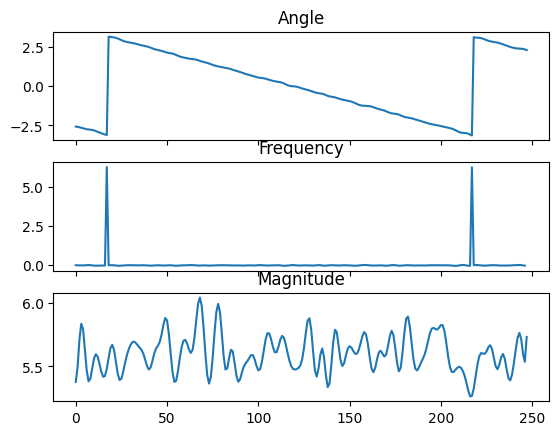

In [24]:
pilot_tone = yhat[pilot_start:pilot_end]
phase_err = np.angle(pilot_tone)
frq_err = phase_err[1:] - phase_err[:-1]
mag_err = np.abs(pilot_tone)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
ax1.set_title('Angle')
ax2.set_title('Frequency')
ax3.set_title('Magnitude')
ax1.plot(phase_err)
ax2.plot(frq_err)
ax3.plot(mag_err)
plt.show()
freq_est = np.mean(frq_err[np.abs(frq_err) < 0.1])
phase_est = np.angle(yhat[pilot_start]) - (freq_est*pilot_start)
mag_est = np.mean(mag_err)


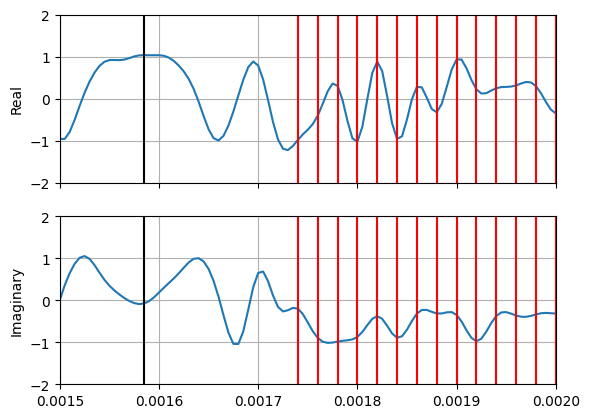

In [25]:
zhat = yhat / (mag_est*np.exp(1j*(np.arange(len(yhat))*freq_est + phase_est)))
fig, ax1, ax2 = plot_complex_time_sequence(zhat, br*sps_rx)
for axis in [ax1, ax2]:
  axis.axvline(x=(t_sps_rx[sync_point]), color='k')
  axis.axvline(x=(t_sps_rx[pilot_end]), color='g')
  axis.axvline(x=(t_sps_rx[pilot_start]), color='g')
  for i in range(len(words)):
    axis.axvline(x=(t_sps_rx[msg_start + (i*sps_rx)]), color='r')
  
# xhat = signal.resample_poly(full_msg, 1, sps//sps_rx, window=rrc) / 120
# ax1.plot(np.arange(len(xhat))/(br*sps_rx), np.real(xhat))
# ax2.plot(np.arange(len(xhat))/(br*sps_rx), np.imag(xhat))

plt.xlim((0.0015, 0.002))
plt.ylim((-2, 2))
plt.show()

In [26]:
mhat = downsample(zhat[msg_start:], sps_rx)[:len(words)]
s_hat = min_dist_detection(mhat, constellation)
print(calc_error_rate(symbs, s_hat))

0.0


In [27]:
w_hat = np.empty_like(s_hat, dtype=np.uint8)
for i in range(M):
  w_hat[s_hat == constellation[i]] = i
print(words2str(w_hat, M))

A perfectly acceptable example of an extremely verbose message of large words and many characters!!!
